<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/WHSAT_bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers pymc arviz scikit-learn

import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/cleaned_safety_data_set_A.csv")

# Keep relevant columns
data_set = df[['description', 'severity']].dropna()

# Convert severity to 0–5
data_set['severity_label'] = data_set['severity'] - 1

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    data_set['description'].tolist(),
    show_progress_bar=True
)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)  # reduce to 100 features
X = pca.fit_transform(embeddings)

y = data_set['severity_label'].values

In [ ]:
from sklearn.model_selection import train_test_split

# Get the original indices from the data_set
indices = data_set.index.values

# Perform the split on indices, using y for stratification
# We get train_idx and test_idx
train_idx, test_idx, _, _ = train_test_split(
    indices, y, test_size=0.2, stratify=y, random_state=42
)

# Use these indices to select the corresponding rows from X and y
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Create test_df by selecting rows from the original data_set using test_idx
test_df = data_set.iloc[test_idx]

In [ ]:
import pymc as pm
import arviz as az

n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))

with pm.Model() as model:

    # Priors
    weights = pm.Normal("weights", mu=0, sigma=1, shape=(n_features, n_classes))
    bias = pm.Normal("bias", mu=0, sigma=1, shape=(n_classes,))

    # Linear model
    logits = pm.math.dot(X_train, weights) + bias

    # Likelihood
    # Use 'logit_p' to pass the logits for the categorical distribution
    y_obs = pm.Categorical("y_obs", logit_p=logits, observed=y_train)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9)

In [ ]:
with model:
    post_pred = pm.sample_posterior_predictive(trace)

# Convert logits to probabilities
logits_samples = trace.posterior['weights'].values

In [ ]:
import scipy.special as sp

def predict_with_uncertainty(X, trace):
    weights_samples = trace.posterior['weights'].values.reshape(-1, n_features, n_classes)
    bias_samples = trace.posterior['bias'].values.reshape(-1, n_classes)

    probs_all = []

    for w, b in zip(weights_samples, bias_samples):
        logits = X @ w + b
        probs = sp.softmax(logits, axis=1)
        probs_all.append(probs)

    probs_all = np.array(probs_all)

    mean_probs = probs_all.mean(axis=0)
    std_probs = probs_all.std(axis=0)

    return mean_probs, std_probs

In [ ]:
import os
import numpy as np

mean_probs, std_probs = predict_with_uncertainty(X_test, trace)

#!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_dir = "/content/drive/MyDrive/WHSAT/"
os.makedirs(save_dir, exist_ok=True)

# Save outputs
np.save(os.path.join(save_dir, "bayesian_mean_probs.npy"), mean_probs)
np.save(os.path.join(save_dir, "bayesian_std_probs.npy"), std_probs)

# Save labels + indices
np.save(os.path.join(save_dir, "y_test.npy"), y_test)
np.save(os.path.join(save_dir, "test_indices.npy"), test_df.index.values)

# Evaluate
y_pred = np.argmax(mean_probs, axis=1)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/Shareddrives': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
Mounted at /content/drive
              precision    recall  f1-score   support

           0       0.74      1.00      0.85        63
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         2

    accuracy                           0.74        85
   macro avg       0.15      0.20      0.17        85
weighted avg       0.55      0.74      0.63        85



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


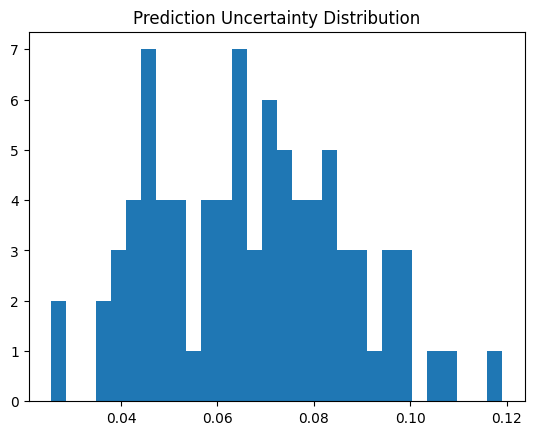

In [ ]:
# Average uncertainty per sample
uncertainty = std_probs.mean(axis=1)

import matplotlib.pyplot as plt
plt.hist(uncertainty, bins=30)
plt.title("Prediction Uncertainty Distribution")
plt.show()